This modified version is:

* Faster
* Finds a better answer

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.utils import shuffle

In [2]:
# data is from: https://grouplens.org/datasets/movielens/
# in case the link changes in the future

!wget -nc http://files.grouplens.org/datasets/movielens/ml-20m.zip

File ‘ml-20m.zip’ already there; not retrieving.



In [3]:
!unzip -n ml-20m.zip

Archive:  ml-20m.zip


In [4]:
!ls

1.PyTorch-Linear-Regression.ipynb
10.PyTorch-Simple-RNN-Sine.ipynb
10.PyTorch-Simple-RNN-Sine1-with-noise.ipynb
11.PyTorch-Understanding-RNN-Shapes.ipynb
12.PyTorch-Nonlinear-Sequence-Simple-RNN.ipynb
12.PyTorch-Nonlinear-Sequence-linear.ipynb
13.PyTorch-Nonlinear-Sequence-LSTM.ipynb
14.PyTorch-RNN-Image-Classifier.ipynb
15.PyTorch-Stock-Returns.ipynb
16.PyTorch-Text-Processing.ipynb
17.Custom-PyTorch-Text-Classification-using-RNN.ipynb
18.Custom-PyTorch-Text-Classification-using-CNN.ipynb
19.PyTorch-Recommender-20M-Unmodified.ipynb
19.PyTorch-Recommender-20M1-Modified.ipynb
2.PyTorch-Regression-Moore's-Law.ipynb
20.PyTorch-Recommender-20M-with-Predictions.ipynb
3.PyTorch-Linear-Classification-with-Logits.ipynb
3.PyTorch-Linear-Classification.ipynb
4.PyTorch-ANN-MNIST.ipynb
5.PyTorch-Regression.ipynb
6.PyTorch-CNN-Fashion-MNIST.ipynb
7.PyTorch-CIFAR.ipynb
8.PyTorch-CIFAR-Improved.ipynb
9.PyTorch-Autoregressive-Model.ipynb
9.PyTorch-Autoregressive-Model1-with-Noise.ipynb
FashionMNIST
MN

In [5]:
df = pd.read_csv('ml-20m/ratings.csv')
df.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


Next I load in the data using pandas and of course the data is a CSV so the first column is the user id, the second is the movie id, and then we have the rating and the timestamp, which we won't need.

In [6]:
# We can't trust the userId and movieId to be numbered 0...N-1
# Let's just set our own ids

# current_user_id = 0
# custom_user_map = {} # old user id > new user id
# def map_user_id(row):
#   global current_user_id, custom_user_map
#   old_user_id = row['userId']
#   if old_user_id not in custom_user_map:
#     custom_user_map[old_user_id] = current_user_id
#     current_user_id += 1
#   return custom_user_map[old_user_id]
# df['new_user_id'] = df.apply(map_user_id, axis=1)

df.userId = pd.Categorical(df.userId)
df['new_user_id'] = df.userId.cat.codes

In [7]:
# Now do the same thing for movie ids
# current_movie_id = 0
# custom_movie_map = {} # old movie id > new movie id
# def map_movie_id(row):
#   global current_movie_id, custom_movie_map
#   old_movie_id = row['movieId']
#   if old_movie_id not in custom_movie_map:
#     custom_movie_map[old_movie_id] = current_movie_id
#     current_movie_id += 1
#   return custom_movie_map[old_movie_id]
# df['new_movie_id'] = df.apply(map_movie_id, axis=1)

df.movieId = pd.Categorical(df.movieId)
df['new_movie_id'] = df.movieId.cat.codes

Then we can grab those ids by calling .cat.codes.

In [8]:
# Get user IDs, movie IDs, and ratings as separate arrays
user_ids = df['new_user_id'].values
movie_ids = df['new_movie_id'].values
ratings = (df['rating'].values - 2.5).astype(np.float32)

In [9]:
# Get number of users and number of movies
N = len(set(user_ids))
M = len(set(movie_ids))

# Set embedding dimension
D = 10

In [10]:
# Make a neural network
class Model(nn.Module):
  def __init__(self, n_users, n_items, embed_dim, n_hidden=1024):
    super(Model, self).__init__()
    self.N = n_users
    self.M = n_items
    self.D = embed_dim

    self.u_emb = nn.Embedding(self.N, self.D)
    self.m_emb = nn.Embedding(self.M, self.D)
    self.fc1 = nn.Linear(2 * self.D, n_hidden)
    self.fc2 = nn.Linear(n_hidden, 1)

    # set the weights since N(0, 1) leads to poor results
    self.u_emb.weight.data = nn.Parameter(
        torch.Tensor(np.random.randn(self.N, self.D) * 0.01))
    self.m_emb.weight.data = nn.Parameter(
        torch.Tensor(np.random.randn(self.M, self.D) * 0.01))

  def forward(self, u, m):
    u = self.u_emb(u) # output is (num_samples, D)
    m = self.m_emb(m) # output is (num_samples, D)

    # merge
    out = torch.cat((u, m), 1) # output is (num_samples, 2D)

    # ANN
    out = self.fc1(out)
    out = F.relu(out)
    out = self.fc2(out)
    return out

In [11]:
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda:0" if torch.cuda.is_available() else "cpu"))
print(device)

mps


in the script there are no more data loaders or data set objects

In [12]:
model = Model(N, M, D)
model.to(device)

Model(
  (u_emb): Embedding(138493, 10)
  (m_emb): Embedding(26744, 10)
  (fc1): Linear(in_features=20, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=1, bias=True)
)

In [13]:
# Loss and optimizer
criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters())
optimizer = torch.optim.SGD(model.parameters(), lr=0.08, momentum=0.9)

You know we create the loss and optimizer and we shuffle the data.

In [14]:
# shuffle the data in corresponding order
user_ids, movie_ids, ratings = shuffle(user_ids, movie_ids, ratings)

This is almost the same as what we did earlier except that this is in pure numpy and we only need to convert the tensor when we're inside the training function. Then we do our inner loop through each batch inside the loop. Next we convert the batch to tensors and move the data to the GPU and we do our usual gradient descent, and don't reinvent the wheel.

In [15]:
def batch_gd2(model, criterion, optimizer, train_data, test_data, epochs, bs=512):
  train_users, train_movies, train_ratings = train_data
  test_users, test_movies, test_ratings = test_data

  train_losses = np.zeros(epochs)
  test_losses = np.zeros(epochs)

  # batches per epoch
  Ntrain = len(train_users)
  batches_per_epoch = int(np.ceil(Ntrain / bs))

  for it in range(epochs):
    t0 = datetime.now()
    train_loss = []

    # shuffle each batch
    train_users, train_movies, train_ratings = shuffle(
        train_users, train_movies, train_ratings
    )

    for j in range(batches_per_epoch):
      # get the batch
      users = train_users[j*bs:(j+1)*bs]
      movies = train_movies[j*bs:(j+1)*bs]
      targets = train_ratings[j*bs:(j+1)*bs]

      # conver to tensor
      users = torch.from_numpy(users).long()
      movies = torch.from_numpy(movies).long()
      targets = torch.from_numpy(targets)

      # reshape targets
      targets = targets.view(-1, 1).float()

      # move data to GPU
      users, movies, targets = users.to(device), movies.to(device), targets.to(device)

      # zero the parameter gradients
      optimizer.zero_grad()

      # Forward pass
      outputs = model(users, movies)
      loss = criterion(outputs, targets)

      # Backward and optimize
      loss.backward()
      optimizer.step()

      train_loss.append(loss.item())

    # Get train loss and test loss
    train_loss = np.mean(train_loss) # a little misleading

    # we could do this if the test set size was manageable
    # test_outputs = model(test_users, test_movies)
    # test_loss = criterion(test_outputs, test_ratings).item()
    test_loss = []
    for j in range(int(np.ceil(len(test_users) / bs))):
      # get the batch
      users = test_users[j*bs:(j+1)*bs]
      movies = test_movies[j*bs:(j+1)*bs]
      targets = test_ratings[j*bs:(j+1)*bs]

      # conver to tensor
      users = torch.from_numpy(users).long()
      movies = torch.from_numpy(movies).long()
      targets = torch.from_numpy(targets)

      # reshape targets
      targets = targets.view(-1, 1).float()

      # move data to GPU
      users, movies, targets = users.to(device), movies.to(device), targets.to(device)

      outputs = model(users, movies)
      loss = criterion(outputs, targets).item()
      test_loss.append(loss)
    test_loss = np.mean(test_loss)

    # Save losses
    train_losses[it] = train_loss
    test_losses[it] = test_loss

    dt = datetime.now() - t0
    print(f'Epoch {it+1}/{epochs}, Train Loss: {train_loss:.4f}, '
          f'Test Loss: {test_loss:.4f}, Duration: {dt}')

  return train_losses, test_losses

In [16]:
Ntrain = int(0.8 * len(ratings))
train_users = user_ids[:Ntrain]
train_movies = movie_ids[:Ntrain]
train_ratings = ratings[:Ntrain]

test_users = user_ids[Ntrain:]
test_movies = movie_ids[Ntrain:]
test_ratings = ratings[Ntrain:]

train_losses, test_losses = batch_gd2(
    model,
    criterion,
    optimizer,
    (train_users, train_movies, train_ratings),
    (test_users, test_movies, test_ratings),
    epochs=10)

Epoch 1/10, Train Loss: 0.7363, Test Loss: 0.6919, Duration: 0:02:29.968585
Epoch 2/10, Train Loss: 0.6688, Test Loss: 0.6707, Duration: 0:02:43.237951
Epoch 3/10, Train Loss: 0.6357, Test Loss: 0.6511, Duration: 0:02:38.554796
Epoch 4/10, Train Loss: 0.6134, Test Loss: 0.6418, Duration: 0:02:45.628034
Epoch 5/10, Train Loss: 0.5976, Test Loss: 0.6328, Duration: 0:02:39.689761
Epoch 6/10, Train Loss: 0.5850, Test Loss: 0.6285, Duration: 0:02:48.035565
Epoch 7/10, Train Loss: 0.5754, Test Loss: 0.6332, Duration: 0:02:37.711529
Epoch 8/10, Train Loss: 0.5680, Test Loss: 0.6269, Duration: 0:02:49.012519
Epoch 9/10, Train Loss: 0.5623, Test Loss: 0.6332, Duration: 0:02:07.638315
Epoch 10/10, Train Loss: 0.5576, Test Loss: 0.6300, Duration: 0:02:12.905682


So here are the results.

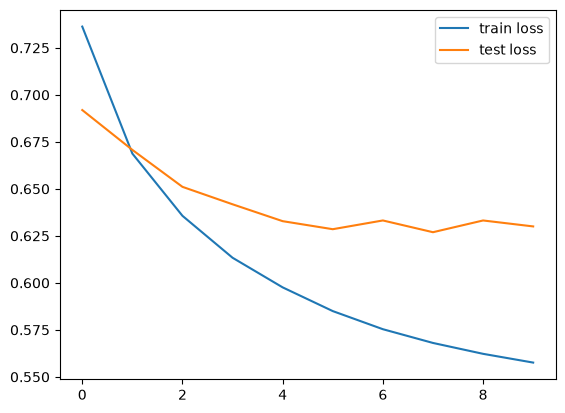

In [17]:
# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.plot(test_losses, label='test loss')
plt.legend()
plt.show()

In [18]:
# Suppose I want to find recommendations for user_id = 1
# First find all the movie_ids for movies they haven't yet watched
watched_movie_ids = df[df.new_user_id == 1].new_movie_id.values

In [19]:
watched_movie_ids

array([   2,   61,   69,  108,  239,  257,  263,  465,  476,  537,  583,
        874,  891,  907, 1098, 1171, 1184, 1188, 1221, 1231, 1242, 1298,
       1326, 1494, 1528, 1616, 1684, 1881, 1885, 1886, 1887, 1888, 1889,
       1890, 1902, 2206, 2369, 2370, 2705, 2772, 2862, 2865, 3063, 3072,
       3086, 3361, 3423, 3443, 3464, 3474, 3612, 3662, 3824, 3825, 3830,
       3833, 3834, 3835, 3837, 3843, 3865], dtype=int16)

In [20]:
potential_movie_ids = df[~df.new_movie_id.isin(watched_movie_ids)].new_movie_id.unique()

In [21]:
# How many?
potential_movie_ids.shape

(26683,)

In [22]:
len(set(potential_movie_ids))

26683

In [23]:
# Repeat the user id this many times
user_id_to_recommend = np.ones_like(potential_movie_ids)

In [24]:
# Convert to torch tensor
t_user_ids = torch.from_numpy(user_id_to_recommend).long().to(device)
t_movie_ids = torch.from_numpy(potential_movie_ids).long().to(device)

# Get predictions
with torch.no_grad():
  predictions = model(t_user_ids, t_movie_ids)

In [25]:
# Convert predictions to Numpy
predictions_np = predictions.cpu().numpy().flatten()

# Get sort index for predictions
sort_idx = np.argsort(-predictions_np)

In [26]:
predictions_np

array([1.4075863 , 0.46886212, 1.4455985 , ..., 1.5210433 , 1.5311444 ,
       1.4805182 ], dtype=float32)

In [27]:
sort_idx

array([   26,    14,    34, ...,  1557,  8529, 13520])

In [28]:
# Top 10 predictions
top_10_movie_ids = potential_movie_ids[sort_idx[:10]]
top_10_scores = predictions_np[sort_idx[:10]]

for movie, score in zip(top_10_movie_ids, top_10_scores):
  print("movie:", movie, "score:", score)

movie: 1173 score: 2.417091
movie: 587 score: 2.3632784
movie: 1212 score: 2.3587108
movie: 1175 score: 2.3564959
movie: 843 score: 2.3408082
movie: 1017 score: 2.3351502
movie: 22964 score: 2.3338575
movie: 20915 score: 2.329484
movie: 453 score: 2.3232489
movie: 1195 score: 2.3139787


Inside the loop as you can see we do in fact get a list of movies with scores sorted in descending order.